# Exercise 1 (3 points)

What does the Central Limit Theorem support in simulation results?

- (a) Independence of variables
- (b) Linear regression validity
- (c) Normality of sampling distribution
- (d) Convergence of time series
- (e) All of the above

C

# Exercise 2 (4 points)

What does convergence in a simulation indicate?

Convergence indicates the stabalization of results where further iterations produce little change in the output

# Exercise 3 (5 points)

Simulate 10,000 rolls of a fair 6-sided die and plot the frequency of each outcome.

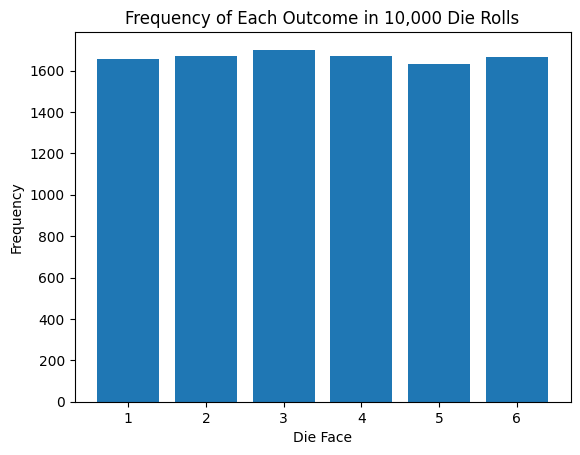

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rolls = np.random.randint(1, 7, size=10000)
counts = np.bincount(rolls)[1:]  # Ignore zero index

plt.bar(range(1, 7), counts)
plt.xlabel('Die Face')
plt.ylabel('Frequency')
plt.title('Frequency of Each Outcome in 10,000 Die Rolls')
plt.show()

# Exercise 4 (4 points)

What is the key limitation of changing multiple coefficients in a simulation at once?

Changing multiple coefficients at once can make it difficult to identify the effect of each individual coefficient and can lead to unclear interpretations

# Exercise 5 (3 points)

What does the burn-in period refer to in simulations?

- (a) The time it takes to prepare the script
- (b) The warm-up iterations before steady-state is reached
- (c) The errors at the end of simulation
- (d) A failed simulation
- (e) None of the above

B

# Exercise 6 (7 points)

Create a trace plot showing convergence of mean die rolls over 5000 iterations.

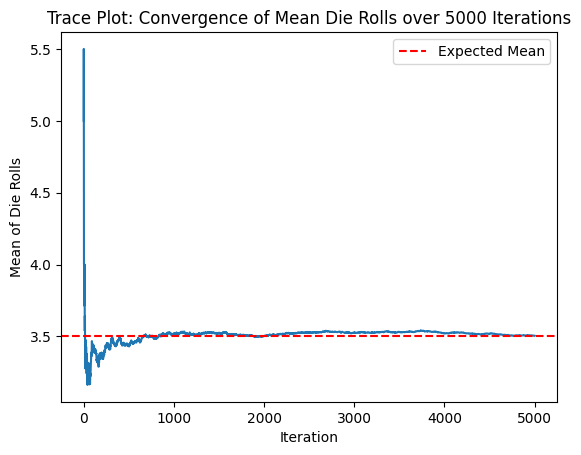

In [8]:
np.random.seed(0)
rolls = np.random.randint(1, 7, size=5000)
means = np.cumsum(rolls) / np.arange(1, 5001)

plt.plot(means)
plt.xlabel('Iteration')
plt.ylabel('Mean of Die Rolls')
plt.title('Trace Plot: Convergence of Mean Die Rolls over 5000 Iterations')
plt.axhline(y=3.5, color='r', linestyle='--', label='Expected Mean')
plt.legend()
plt.show()

# Exercise 7 (3 points)

In simulation, what kind of variables does the triangular distribution model best?

- (a) Bounded continuous variables with known extremes and mode
- (b) Binary
- (c) Discrete uniform
- (d) Time-based events
- (e) All of the above

A

# Exercise 8 (7 points)

Simulate 1000 iterations of annualized return over 10 years assuming yearly returns follow a normal distribution with 7% mean and 15% standard deviation. Visualize the returns with a histogram.

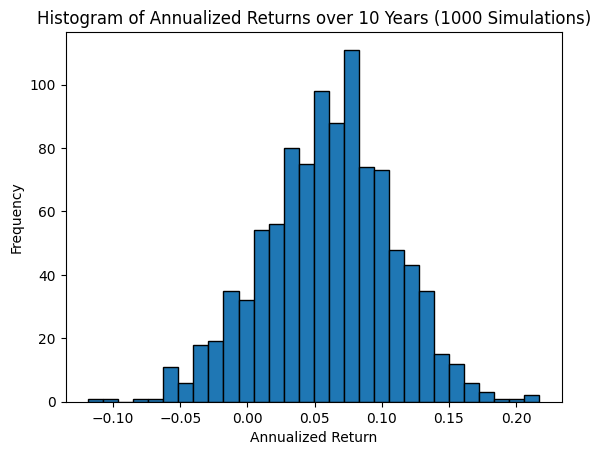

In [9]:
np.random.seed(42)
n_simulations = 1000
years = 10
mean = 0.07
std = 0.15

annualized_returns = []
for _ in range(n_simulations):
    yearly_returns = np.random.normal(mean, std, years)
    total_return = np.prod(1 + yearly_returns)
    annualized = total_return ** (1 / years) - 1
    annualized_returns.append(annualized)

plt.hist(annualized_returns, bins=30, edgecolor='black')
plt.xlabel('Annualized Return')
plt.ylabel('Frequency')
plt.title('Histogram of Annualized Returns over 10 Years (1000 Simulations)')
plt.show()

# Exercise 9 (8 points)

Perform bootstrapping to estimate the standard error of a linear regression coefficient. Consider the below code snippet:

```
import pandas as pd

# Generate sample data
np.random.seed(1)
x = np.random.rand(100)
y = 2 * x + np.random.normal(0, 0.1, 100)
df = pd.DataFrame({'x': x, 'y': y})

```

Take 1,000 bootstrap samples from `df`. For each bootstrap sample, estimate the slope of the line and store the values in a list. Visualize the estimated slopes using a histogram and report the standard deviation of these estimated slopes.

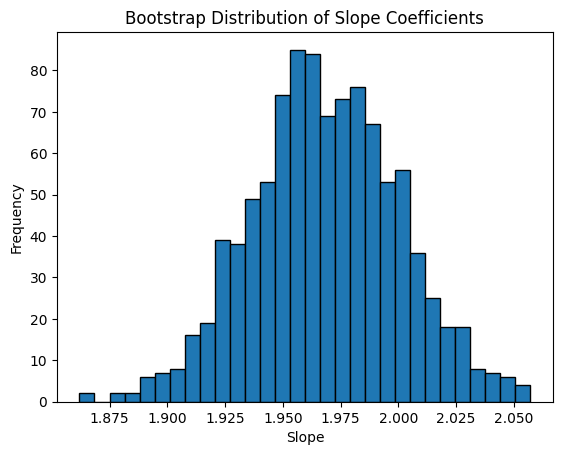

standard deviation of slopes: 0.03184021265393826


In [10]:
import pandas as pd

# Generate sample data
np.random.seed(1)
x = np.random.rand(100)
y = 2 * x + np.random.normal(0, 0.1, 100)
df = pd.DataFrame({'x': x, 'y': y})

bootstaps = 1000
slopes = []
for _ in range(bootstaps):
    sample = df.sample(n=100, replace=True)
    slope = np.polyfit(sample['x'], sample['y'], 1)[0]
    slopes.append(slope)
    
plt.hist(slopes, bins=30, edgecolor='black')
plt.xlabel('Slope')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution of Slope Coefficients')
plt.show()

print('standard deviation of slopes:', np.std(slopes))